# Recognizing multi-digit numbers in photographs captured at street level

## Importing Libraries

In [ ]:
import numpy as np
import h5py
import matplotlib.pyplot as plt

In [ ]:
import tensorflow as tf

## Data Fetching

In [ ]:
!gdown --id 1L2-WXzguhUsCArrFUc8EEkXcj33pahoS

Downloading...
From: https://drive.google.com/uc?id=1L2-WXzguhUsCArrFUc8EEkXcj33pahoS
To: /content/SVHN_single_grey1.h5
492MB [00:03, 132MB/s]


In [ ]:
h5f=h5py.File('SVHN_single_grey1.h5','r')

We split the dataset into two parts: training and testing. Each of these parts have their corresponding inputs (X) and outputs (y).

In [ ]:
X_train=h5f['X_train'][:]
y_train=h5f['y_train'][:]

X_test=h5f['X_test'][:]
y_test=h5f['y_test'][:]

### Normalizing the dataset 

Here we transform the values of image pixels between 0 and 1

In [ ]:
X_train=X_train/255
X_test=X_test/255

In [ ]:
h5f.close()

## Understanding the dataset

In [ ]:
We explore the shapes of the data.

In [ ]:
print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)

(42000, 32, 32)
(42000,)
(18000, 32, 32)
(18000,)


In [ ]:
plt.gray()

<Figure size 432x288 with 0 Axes>

We plot a sample data.

7


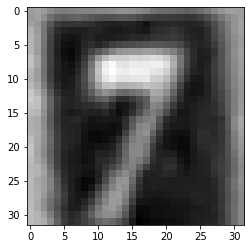

In [ ]:
img=2
plt.imshow(X_train[img])

We reshape the dataset to include a dimension for the number of channels, in our case 1.

In [ ]:
X_train=X_train.reshape(X_train.shape[0],32,32,1)
X_test=X_test.reshape(X_test.shape[0],32,32,1)

We convert the output values into one-hot encoding.

In [ ]:
y_train = tf.keras.utils.to_categorical(y_train)
y_test = tf.keras.utils.to_categorical(y_test)


## Creating model

Here we create out feed forward neural network model. The types of layers included in the model are:


*   Dense Layer 
*   Convolution Layer
*   Dropout Layer
*   Flatten
*   Batch Normalization

The network is a Convolutional Feedforward neural network, which is good for image data. Batch normalization is used to standardize the inputs to a layer for each mini-batch. Dropout is used to prevent overfitting.

For the hidden layers, ReLU activation function has been used. 
For the output layer, Softmax activation function has been used. 

In [ ]:
model = tf.keras.models.Sequential()

model.add(tf.keras.layers.Convolution2D(32, 3, 3, activation='relu', input_shape=(32,32,1)))
model.add(tf.keras.layers.Convolution2D(28, 3, 3, activation='relu'))
model.add(tf.keras.layers.Convolution2D(16, 3, 3, activation='relu'))
model.add(tf.keras.layers.Dropout(0.1))

model.add(tf.keras.layers.BatchNormalization())

model.add(tf.keras.layers.Flatten())

model.add(tf.keras.layers.Dense(128, activation='relu'))
model.add(tf.keras.layers.Dense(64, activation='relu'))
model.add(tf.keras.layers.Dense(32, activation='relu'))
model.add(tf.keras.layers.Dropout(0.1))

model.add(tf.keras.layers.Dense(10, activation='softmax'))

model.summary()

Model: "sequential_19"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
conv2d_42 (Conv2D)           (None, 10, 10, 32)        320       
_________________________________________________________________
conv2d_43 (Conv2D)           (None, 3, 3, 28)          8092      
_________________________________________________________________
conv2d_44 (Conv2D)           (None, 1, 1, 16)          4048      
_________________________________________________________________
dropout_31 (Dropout)         (None, 1, 1, 16)          0         
_________________________________________________________________
batch_normalization_9 (Batch (None, 1, 1, 16)          64        
_________________________________________________________________
flatten_6 (Flatten)          (None, 16)                0         
_________________________________________________________________
dense_37 (Dense)             (None, 128)             

Categorical crossentropy is the loss function which is used here.
Adam optimizer has been used. 

In [ ]:
model.compile(loss='categorical_crossentropy',optimizer='adam',metrics=['accuracy'])

The model will now be trained. It will be trained for 50 epochs. The training dataset is split into two parts: training data and validation data (which includes 20% of the initial training data samples.)

In [ ]:
history=model.fit(X_train, y_train, epochs=50, validation_split=0.2,verbose=1)

Epoch 1/50
1050/1050 [==============================] - 4s 3ms/step - loss: 2.1790 - accuracy: 0.1647 - val_loss: 1.5851 - val_accuracy: 0.4511
Epoch 2/50
1050/1050 [==============================] - 4s 4ms/step - loss: 1.6014 - accuracy: 0.4517 - val_loss: 1.2262 - val_accuracy: 0.5960
Epoch 3/50
1050/1050 [==============================] - 3s 3ms/step - loss: 1.3727 - accuracy: 0.5428 - val_loss: 1.1253 - val_accuracy: 0.6313
Epoch 4/50
1050/1050 [==============================] - 3s 3ms/step - loss: 1.2475 - accuracy: 0.5853 - val_loss: 0.9935 - val_accuracy: 0.6858
Epoch 5/50
1050/1050 [==============================] - 3s 3ms/step - loss: 1.1918 - accuracy: 0.6037 - val_loss: 0.9381 - val_accuracy: 0.6961
Epoch 6/50
1050/1050 [==============================] - 3s 3ms/step - loss: 1.1468 - accuracy: 0.6218 - val_loss: 0.9243 - val_accuracy: 0.7151
Epoch 7/50
1050/1050 [==============================] - 3s 3ms/step - loss: 1.1045 - accuracy: 0.6404 - val_loss: 0.9309 - val_accuracy:

We can see that the model gives around 77% accuracy on the training set 80% accuracy on the validation set.

In [ ]:
result=model.evaluate(X_test,y_test)
print("Test Set Accuracy: ",result[1])

563/563 [==============================] - 1s 2ms/step - loss: 0.6303 - accuracy: 0.8074
Test Set Accuracy:  0.8073889017105103


We see that the model gives around 80% accuracy on the test set.